In [1]:
# Libraries
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('default')
%matplotlib inline
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mpdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input, LSTM, Dense, concatenate
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt


In [2]:
# Load dataset
df_compiled = pd.read_csv('compiled_datasets.csv', parse_dates=['Date'], index_col='Date')
df_compiled.loc['2019-01-01':'2025-01-01'].dropna()
df_compiled.columns.tolist()

['Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'headline',
 'TextBlob_Polarity',
 'TextBlob_Subjectivity',
 'TextBlob_Sentiment',
 'VADER_Score',
 'VADER_Sentiment',
 'Close_Change',
 'VADER_Sentiment_Num',
 'Close_lag_1',
 'VADER_Score_lag_1',
 'Close_lag_2',
 'VADER_Score_lag_2',
 'Close_lag_3',
 'VADER_Score_lag_3',
 'SMA_5',
 'EMA_5',
 'RSI_14',
 'MACD',
 'MACD_signal',
 'MACD_hist']

In [3]:
df_compiled.head()

,Close,High,Low,Open,Volume,headline,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Sentiment,VADER_Score,...,Close_lag_2,VADER_Score_lag_2,Close_lag_3,VADER_Score_lag_3,SMA_5,EMA_5,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500.0,NaN,0.0,0.0,Neutral,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000.0,NaN,0.0,0.0,Neutral,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500.0,NaN,0.0,0.0,Neutral,0.0,...,1675.829956,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900.0,NaN,0.0,0.0,Neutral,0.0,...,1669.780029,0.0,1675.829956,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-09,1667.829956,1684.079956,1667.829956,1679.060059,176278400.0,NaN,0.0,0.0,Neutral,0.0,...,1679.170044,0.0,1669.780029,0.0,1673.073999,1673.073999,NaN,NaN,NaN,NaN


In [4]:
# Re-scale VADER Sentiment
df_compiled['VADER_Sentiment'] = df_compiled['VADER_Sentiment'].replace({
    'Neutral': 0.0,
    'Positive': 1.0,
    'Negative': -1.0
})


C:\Users\badar\AppData\Local\Temp\ipykernel_16164\3285919984.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_compiled['VADER_Sentiment'] = df_compiled['VADER_Sentiment'].replace({


In [5]:
# Re-scale TextBlob Sentiment
df_compiled['TextBlob_Sentiment'] = df_compiled['TextBlob_Sentiment'].replace({
    'Neutral': 0.0,
    'Positive': 1.0,
    'Negative': -1.0
})


C:\Users\badar\AppData\Local\Temp\ipykernel_16164\3566160557.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_compiled['TextBlob_Sentiment'] = df_compiled['TextBlob_Sentiment'].replace({


In [6]:
df_compiled['VADER_Sentiment'] = pd.to_numeric(df_compiled['VADER_Sentiment'], errors='coerce')
df_compiled['TextBlob_Sentiment'] = pd.to_numeric(df_compiled['TextBlob_Sentiment'], errors='coerce')


In [7]:
# Feature Setup 
tech_feats = ['Open', 'High', 'Low', 'Volume', 'RSI_14', 'MACD']  
senti_feats = ['VADER_Score', 'VADER_Sentiment']  

# Target column
target_col = 'Close'

In [8]:
# Split the Data (No Leakage)
# Chronological split (e.g., 80% train, 20% test)
split_index = int(len(df_compiled) * 0.8)
train_df = df_compiled.iloc[:split_index].copy()
test_df = df_compiled.iloc[split_index:].copy()


In [9]:
# Initialize scalers
scaler_tech = MinMaxScaler()
scaler_senti = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit only on training data
train_tech = scaler_tech.fit_transform(train_df[tech_feats])
test_tech = scaler_tech.transform(test_df[tech_feats])

train_senti = scaler_senti.fit_transform(train_df[senti_feats])
test_senti = scaler_senti.transform(test_df[senti_feats])

train_y = scaler_y.fit_transform(train_df[[target_col]])
test_y = scaler_y.transform(test_df[[target_col]])


In [10]:
# Build Time-Series Sequences
seq_len = 60 #60-days sequence

def create_sequences(features1, features2, targets, seq_len):
    X1, X2, y = [], [], []
    for i in range(seq_len, len(features1)):
        X1.append(features1[i-seq_len:i])
        X2.append(features2[i-seq_len:i])
        y.append(targets[i])
    return np.array(X1), np.array(X2), np.array(y)

X_train_tech, X_train_senti, y_train = create_sequences(train_tech, train_senti, train_y, seq_len)
X_test_tech, X_test_senti, y_test = create_sequences(test_tech, test_senti, test_y, seq_len)


In [11]:
# Build the Hybrid Two-Stream LSTM Model
tech_in = Input(shape=(seq_len, len(tech_feats)), name='tech_input')
x1 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(tech_in)
x1 = BatchNormalization()(x1)
x1 = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(x1)

senti_in = Input(shape=(seq_len, len(senti_feats)), name='senti_input')
x2 = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(senti_in)

# Merge
merged = concatenate([x1, x2])
x = Dense(64, activation='relu')(merged)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, name='pred_close')(x)

model = Model([tech_in, senti_in], output)

# Compile with regression metrics
model.compile(optimizer='adam', loss='mse', metrics=[
        RootMeanSquaredError(name='rmse'),
        MeanAbsoluteError(name='mae')
    ]
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tech_input          │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 256)   │    138,240 │ tech_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ senti_input         │ (None, 60, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     82,176 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     17,152 │ senti_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred_close (Dense)  │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 248,961 (972.50 KB)

 Trainable params: 248,449 (970.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [12]:
# Train-test data
history = model.fit(
    x=[X_train_tech, X_train_senti], 
    y=y_train,
    validation_data=([X_test_tech, X_test_senti], y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 251ms/step - loss: 0.3793 - mae: 0.5953 - rmse: 0.6158 - val_loss: 0.5028 - val_mae: 0.7039 - val_rmse: 0.7091
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 239ms/step - loss: 0.3297 - mae: 0.5507 - rmse: 0.5742 - val_loss: 0.4563 - val_mae: 0.6701 - val_rmse: 0.6755
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 227ms/step - loss: 0.2947 - mae: 0.5189 - rmse: 0.5429 - val_loss: 0.4134 - val_mae: 0.6372 - val_rmse: 0.6429
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - loss: 0.2669 - mae: 0.4924 - rmse: 0.5165 - val_loss: 0.3738 - val_mae: 0.6054 - val_rmse: 0.6114
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - loss: 0.2393 - mae: 0.4625 - rmse: 0.4891 - val_loss: 0.3376 - val_mae: 0.5747 - val_rmse: 0.5810
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step - loss: 0.2071 - mae: 0.4268 - rmse: 0.4550 - val_loss: 0.3047 - val_mae: 0.5454 - val_rmse: 0.5520
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - loss: 0.1791 - mae: 0.3934 - rmse

In [28]:
# Prediction and Inverse Transform
y_pred_scaled = model.predict([X_test_tech, X_test_senti])

# Inverse transform both predictions and actual test values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
r2 = r2_score(y_test, y_pred_scaled)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 0.15
RMSE: 0.16
R² Score: -2.74


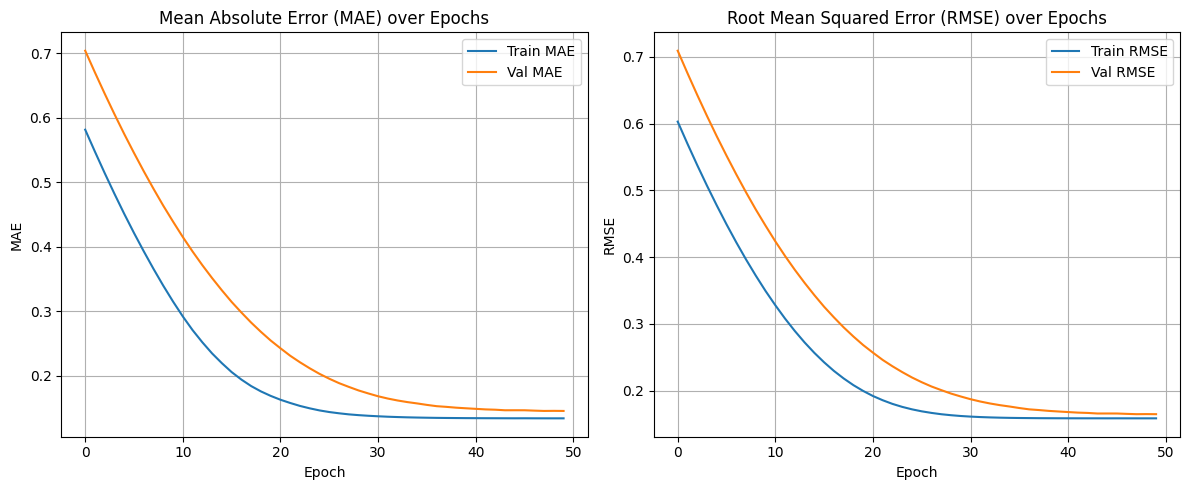

In [40]:
# Plot MAE and RMSE over training epochs
plt.figure(figsize=(12, 5))

# MAE
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error (MAE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

# RMSE
plt.subplot(1, 2, 2)
plt.plot(history.history['rmse'], label='Train RMSE')
plt.plot(history.history['val_rmse'], label='Val RMSE')
plt.title('Root Mean Squared Error (RMSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


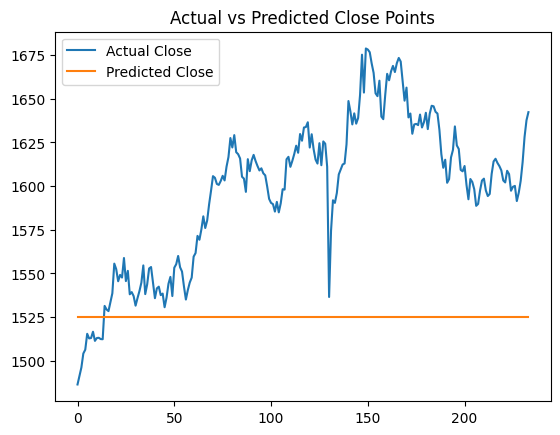

In [47]:
# Predicted KLCI 
plt.plot(y_test_inv, label='Actual Close')
plt.plot(y_pred, label='Predicted Close')
plt.title('Actual vs Predicted Close Points')
plt.legend()
plt.show()


In [16]:
print("Sample y_pred (scaled):", y_pred_scaled[:5].flatten())
print("Sample y_pred (actual):", y_pred[:5].flatten())


Sample y_pred (scaled): [0.5973924 0.5973924 0.5973924 0.5973924 0.5973924]
Sample y_pred (actual): [1524.9636 1524.9636 1524.9636 1524.9636 1524.9636]


In [17]:
# Check Training Target Distribution
print("y_train min/max/mean/std:", 
      y_train.min(), y_train.max(), 
      y_train.mean(), y_train.std()
      )


y_train min/max/mean/std: 0.0 0.9223421652091544 0.598294176417964 0.15874937784009355


In [18]:
# Simulate Two-Year Forecast
last_tech = X_test_tech[-1:]
last_senti= X_test_senti[-1:]
future = []

for _ in range(504):  # approx 2 trading years
    pred = model.predict([last_tech, last_senti])[0,0]
    future.append(pred)

    # shift and append new data (you can loop forward your close and sentiment)
    last_tech = np.roll(last_tech, -1, axis=1)
    last_tech[0,-1,:] = np.concatenate([last_tech[0,-1,:len(tech_feats)-1], last_tech[0,-1,-1:]])  # placeholder
    last_senti = np.roll(last_senti, -1, axis=1)
    last_senti[0,-1,:] = last_senti[0,-1,:]  # placeholder


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━

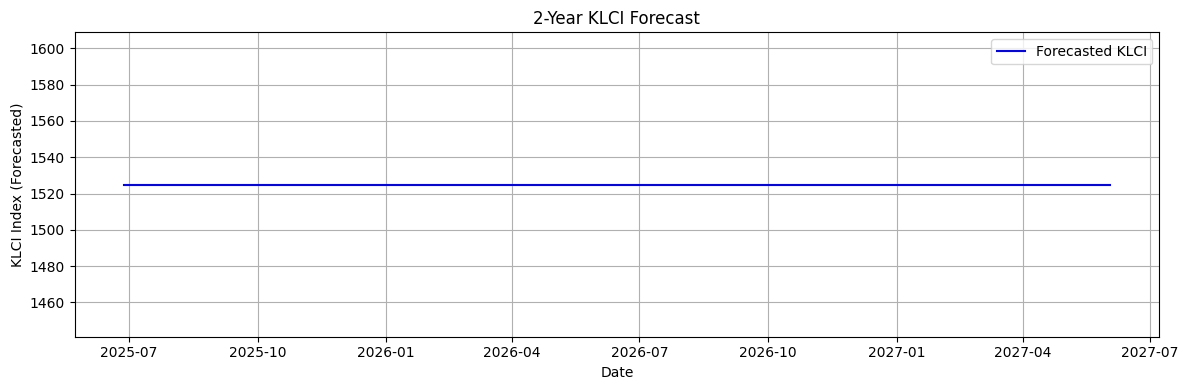

In [19]:

# Convert future predictions back to actual values
future_array = np.array(future).reshape(-1, 1)
future_real = scaler_y.inverse_transform(future_array).flatten()

# Generate business day dates for forecast horizon
# Get the last date from y_pred (must be a DataFrame/Series with datetime index)
last_known_date = y_pred.index[-1] if hasattr(y_pred, 'index') else pd.to_datetime('today')

# Create future business days (skip first to avoid repeating the last known date)
forecast_dates = pd.date_range(start=last_known_date, periods=len(future_real)+1, freq='B')[1:]

# Step 3: Plot the forecast
plt.figure(figsize=(12, 4))
plt.plot(forecast_dates, future_real, color='blue', label='Forecasted KLCI')
plt.title('2-Year KLCI Forecast')
plt.xlabel('Date')
plt.ylabel('KLCI Index (Forecasted)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
y_train.min()

np.float64(0.0)

In [45]:
def smape(y_true, y_pred):
    numerator = tf.abs(y_pred - y_true)
    denominator = (tf.abs(y_true) + tf.abs(y_pred)) / 2.0 + tf.keras.backend.epsilon()
    return 100 * tf.reduce_mean(numerator / denominator)


In [46]:
model.compile(optimizer='adam', loss='mse', metrics=[smape, 'mae', 'rmse'])
